### This code provides supports for results on Analyses of Mobility Pattern, including those in Main Text section 2.1.

In [1]:
import pandas as pd
from linearmodels.panel import PanelOLS, RandomEffects, compare
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm


d:\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# ##process data
# import glob
# import numpy as np
# import os
# import ast

# df_census = pd.read_csv('D:/main/1_research/P10_Mobility/p10_aging mobility/new data/census/all_census_data_with_location.csv')

# path = 'D:/main/1_research/P10_Mobility/p10_aging mobility/new data/Mobility/04'


# allfiles=[]
# for name in glob.glob('D:/main/1_research/P10_Mobility/p10_aging mobility/new data/Mobility/04/*', recursive=True):
#     file= glob.glob(name + '/*.csv.gz', recursive=True)
#     allfiles.append(file[0])

# df_list=[]
# for i,filename in enumerate(allfiles):
#     df = pd.read_csv(filename)

#     df1 = df.merge(df_census, left_on='origin_census_block_group', right_on='census_block_group')

#     df1['C'] =df1.apply(lambda x: 'less than 0.2' if x['percent_above_65']<0.2 else 'mid', axis=1)
#     df1['C'] =df1.apply(lambda x: 'greater than 0.5' if x['percent_above_65']>0.5 else x['C'], axis=1)

#     df1 = df1.loc[df1['distance_traveled_from_home']<=df1['distance_traveled_from_home'].quantile(0.99)]


#     result = [ast.literal_eval(x) for x in list(df1['destination_cbgs'])] #convert the strings of the columns of destination_cbgs to dictionary

#     df_ = pd.DataFrame(columns=['dest_bg','number of visits'])  
#     df_ = pd.DataFrame([(i, j) for a in result for i, j in a.items()], columns=['dest_bg','number of visits']) 

#     result_length = [len(item) for item in result]
#     df_temp = pd.DataFrame()
#     df_temp['orig_bg'] = df1['origin_census_block_group']
#     df_temp['num'] = result_length
#     df_temp['C'] = df1['C']
#     df_temp = df_temp.reindex(df_temp.index.repeat(df_temp.num))
#     df_temp.reset_index(drop=True, inplace=True)

#     df_['orig_bg'] = df_temp['orig_bg']
#     df_['C'] = df_temp['C']
#     df_['dest_bg'] = df_['dest_bg'].astype('int64')


#     df_ = df_.loc[df_['orig_bg']!=df_['dest_bg']]
#     sum_visits = df_.groupby('orig_bg')['number of visits'].sum().reset_index()

#     df1 = df1.merge(sum_visits, left_on='origin_census_block_group', right_on='orig_bg')

#     print(filename)

#     x1=list(df1.loc[df1['C']=='greater than 0.5']['distance_traveled_from_home'])
#     y1=list(df1.loc[df1['C']=='greater than 0.5']['number of visits'])
#     z1=list(df1.loc[df1['C']=='greater than 0.5']['median_percentage_time_home'])

#     cbg1=list(df1.loc[df1['C']=='greater than 0.5']['origin_census_block_group'])

#     df_a = pd.DataFrame({'census_block_group':cbg1,'Distance traveled from home': x1,'Number of visits': y1,'Median_percentage_time_home': z1,
#                         'Percentage above age 65': 'greater than 0.5', 'Day': (i+1)*np.ones(len(x1))})

#     x2=list(df1.loc[df1['C']=='less than 0.2']['distance_traveled_from_home'])
#     y2=list(df1.loc[df1['C']=='less than 0.2']['number of visits'])
#     z2=list(df1.loc[df1['C']=='less than 0.2']['median_percentage_time_home'])

#     cbg2=list(df1.loc[df1['C']=='less than 0.2']['origin_census_block_group'])

#     df_b = pd.DataFrame({'census_block_group':cbg2,'Distance traveled from home': x2,'Number of visits': y2, 'Median_percentage_time_home': z2, 
#                         'Percentage above age 65': 'less than 0.2', 'Day': (i+1)*np.ones(len(x2))})
#     df_c=pd.concat([df_b,df_a])

#     df_list.append(df_c)

# df_all_mob=pd.concat(df_list)

# df_all_mob=df_all_mob.rename(columns={'Median_percentage_time_home':'% of Time Spent at Home'  })

# df_all_mob.to_csv(r"D:\main\1_research\P10_Mobility\p10_aging mobility\R1\new results\mobility\US_distribution_mobility_pattern_50_20.csv")

In [3]:
###data source
#df_all_mob=pd.read_csv("data/mobility/US_distribution_mobility_pattern_50_20.csv")
df_head=pd.read_csv("data/mobility/Part1_US_distribution_mobility_pattern_50_20.csv")
df_mid=pd.read_csv("data/mobility/Part2_US_distribution_mobility_pattern_50_20.csv")
df_tail=pd.read_csv("data/mobility/Part3_US_distribution_mobility_pattern_50_20.csv")
df_all_mob=pd.concat([df_head,df_mid,df_tail]).reset_index(drop=True)

df_census = pd.read_csv('data/census/all_census_data_with_location.csv')
###data source

In [4]:


df=df_census[['census_block_group','percent_above_65','isUrban']]
df['age']=df.apply(lambda x: 1 if x['percent_above_65']>0.5 else 0.5,axis=1 )
df['age']=df.apply(lambda x: 0 if x['percent_above_65']<0.2 else x['age'],axis=1 )
df_all_mob=pd.merge(df_all_mob,df,how='left',on='census_block_group') 


C:\Users\Linao\AppData\Local\Temp\ipykernel_9220\2837907121.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['age']=df.apply(lambda x: 1 if x['percent_above_65']>0.5 else 0.5,axis=1 )
C:\Users\Linao\AppData\Local\Temp\ipykernel_9220\2837907121.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['age']=df.apply(lambda x: 0 if x['percent_above_65']<0.2 else x['age'],axis=1 )


In [5]:
df_all_mob 

,census_block_group,Distance traveled from home,Number of visits,% of Time Spent at Home,Percentage above age 65,Day,percent_above_65,isUrban,age
0,10730049022,3150,222,90,less than 0.2,1.0,0.071146,1,0.0
1,11210118001,1727,96,84,less than 0.2,1.0,0.197684,1,0.0
2,11250106021,4456,620,74,less than 0.2,1.0,0.115077,0,0.0
3,21880002003,305,14,0,less than 0.2,1.0,0.099222,0,0.0
4,40019450014,2050,53,0,less than 0.2,1.0,0.138671,0,0.0
...,...,...,...,...,...,...,...,...,...
4938328,120990054051,6244,41,2,greater than 0.5,30.0,0.637076,1,1.0
4938329,370899319012,5539,135,84,greater than 0.5,30.0,0.510778,1,1.0
4938330,120090711002,1652,276,67,greater than 0.5,30.0,0.688245,1,1.0
4938331,40130405252,2453,13,100,greater than 0.5,30.0,0.744485,1,1.0


In [6]:
print(df_all_mob[df_all_mob['age']!=0.5].set_index(['census_block_group', 'Day'])[['isUrban', 'age']].describe())

            isUrban           age
count  4.938333e+06  4.938333e+06
mean   8.514608e-01  1.361634e-02
std    3.556337e-01  1.158919e-01
min    0.000000e+00  0.000000e+00
25%    1.000000e+00  0.000000e+00
50%    1.000000e+00  0.000000e+00
75%    1.000000e+00  0.000000e+00
max    1.000000e+00  1.000000e+00


In [7]:

df = df_all_mob[df_all_mob['age']!=0.5]




X = df[['isUrban', 'age','Day']]



X = sm.add_constant(X)

for yy in ['Distance traveled from home','Number of visits','% of Time Spent at Home']:
    y = (df[yy] - df[yy].min()) / (df[yy].max() - df[yy].min())
 
    ols_model = sm.OLS(y, X).fit()
    print(yy)
    print(ols_model.summary())

Distance traveled from home
                                 OLS Regression Results                                
Dep. Variable:     Distance traveled from home   R-squared:                       0.118
Model:                                     OLS   Adj. R-squared:                  0.118
Method:                          Least Squares   F-statistic:                 2.194e+05
Date:                         Thu, 20 Mar 2025   Prob (F-statistic):               0.00
Time:                                 22:13:09   Log-Likelihood:             3.5789e+06
No. Observations:                      4938333   AIC:                        -7.158e+06
Df Residuals:                          4938329   BIC:                        -7.158e+06
Df Model:                                    3                                         
Covariance Type:                     nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------

In [8]:
df_all_mob

,census_block_group,Distance traveled from home,Number of visits,% of Time Spent at Home,Percentage above age 65,Day,percent_above_65,isUrban,age
0,10730049022,3150,222,90,less than 0.2,1.0,0.071146,1,0.0
1,11210118001,1727,96,84,less than 0.2,1.0,0.197684,1,0.0
2,11250106021,4456,620,74,less than 0.2,1.0,0.115077,0,0.0
3,21880002003,305,14,0,less than 0.2,1.0,0.099222,0,0.0
4,40019450014,2050,53,0,less than 0.2,1.0,0.138671,0,0.0
...,...,...,...,...,...,...,...,...,...
4938328,120990054051,6244,41,2,greater than 0.5,30.0,0.637076,1,1.0
4938329,370899319012,5539,135,84,greater than 0.5,30.0,0.510778,1,1.0
4938330,120090711002,1652,276,67,greater than 0.5,30.0,0.688245,1,1.0
4938331,40130405252,2453,13,100,greater than 0.5,30.0,0.744485,1,1.0


d:\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
d:\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
d:\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


Distance traveled from home 1885.5 2170.5


d:\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
d:\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
d:\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


Number of visits 68.5 110.0


d:\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
d:\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
d:\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


Percentage of time spent at home 88.0 78.0


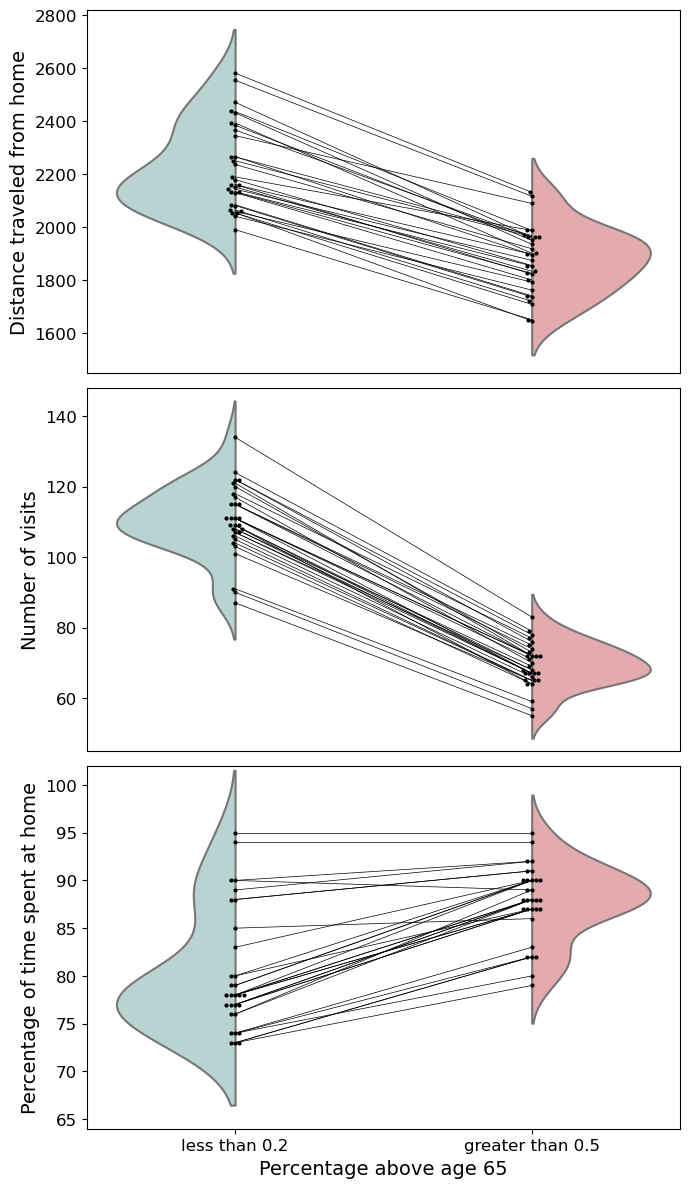

In [9]:
#plot pattern difference using violin plots
colorlist=['#B3D8D5', '#EDA1A4']
colors={'less than 0.2':'#B3D8D5','greater than 0.5': '#EDA1A4'}

fig,ax =plt.subplots(3,1,figsize=(7,12))
ylim_dict={"Distance traveled from home":[1450,2820],"Number of visits":[45,148],"% of Time Spent at Home":[64,102]}

rename_dict={"Distance traveled from home":"Distance traveled from home",
             "Number of visits":"Number of visits",
             "% of Time Spent at Home":"Percentage of time spent at home"}
for i,metric in enumerate(["Distance traveled from home","Number of visits","% of Time Spent at Home"]):
    x1 = []
    x2 = []
    for d in range(30):
        day=d+1
        x1.append(np.median(df_all_mob[(df_all_mob['Percentage above age 65']!='less than 0.2')&
                   (df_all_mob['Day']==day)][metric]))
        x2.append(np.median(df_all_mob[(df_all_mob['Percentage above age 65']=='less than 0.2')&
                   (df_all_mob['Day']==day)][metric]))          
    
    # Create a DataFrame from the data
    df1 = pd.DataFrame({metric: x2, 'Percentage above age 65': 'less than 0.2', 'half': np.zeros(len(x1)),
                        'color':'#b3e2cd'})
    df2 = pd.DataFrame({metric: x1, 'Percentage above age 65': 'greater than 0.5', 'half': np.ones(len(x2)),
                        'color':'#fc8d62'})

    # Combine into one DataFrame
    df = pd.concat([df1, df2]).reset_index()
    df['pair_index'] = list(range(0,30))*2
    #print(df)


    # Create violinplot for x1 and x2
    sns.violinplot(ax=ax[i],x="Percentage above age 65", y=metric, hue="half", data=df, split=True, inner=None,scale='area',
                  palette=colors.values())

    # Overlay swarmplot on top of violinplot for x1 and x2
    sns.swarmplot(ax=ax[i],x="Percentage above age 65", y=metric, data=df, color='k', size=3)

    # Get x coordinates for lines
    x_coords = df.groupby('pair_index')['Percentage above age 65'].apply(list)

    # Get y coordinates for lines
    y_coords = df.groupby('pair_index')[metric].apply(list)

    
    # Draw lines between each pair of points
    for j in range(len(x1)):
        ax[i].plot(x_coords[j], y_coords[j], 'k-', linewidth=0.5)

    # Remove legend
    ax[i].legend().remove()
    ax[i].set_xlim([-0.5,1.5])
    ylow=min(min(x1),min(x2))-5
    yhigh=max(max(x1),max(x2))+5
    ax[i].set_ylim(ylim_dict[metric])   
    
    print(rename_dict[metric],np.median(x1),np.median(x2))
    
    if i<2:
        
        ax[i].set_xlabel('')
        ax[i].set_xticks([])
    else:
        ax[i].set_xlabel('Percentage above age 65', fontsize=14)
        xticks = ax[i].get_xticklabels()

        for tick in xticks:
            tick.set_fontsize(12)  # 
            #tick.set_fontweight('bold')  # 
    ax[i].set_ylabel(rename_dict[metric], fontsize=14)
    
    yticks = ax[i].get_yticklabels() 
    for tick in yticks:
        tick.set_fontsize(12)  # 
        #tick.set_fontweight('bold')  # 
plt.tight_layout()
plt.show()

In [10]:
#fig.savefig('D:/main/1_research/P10_Mobility/p10_aging mobility/results_all_states/MobilityResults/countryLevelData-Figure/3metrics_distribution_mobility_pattern_50_20.jpg',
#            dpi=600,bbox_inches='tight')